In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import tarfile
import urllib.request
import pandas as pd
import seaborn as sns

def load_housing_data():
    # Corrected file path with raw string to handle backslashes properly
    tarball_path = Path(r"C:\Users\navee\OneDrive\Desktop\PRIYA DOCUMENT\housing.tgz.tar")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")

    return pd.read_csv("C:\\Users\\navee\\OneDrive\\Desktop\\PRIYA DOCUMENT\\housing.csv.zip")

# Load the dataset
housing = load_housing_data()

# Load the dataset (use your path to the dataset if needed)
housing = pd.read_csv("C:\\Users\\navee\\OneDrive\\Desktop\\PRIYA DOCUMENT\\housing.csv")

housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
housing.dropna(subset=['total_bedrooms'], inplace=True)  

In [6]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [7]:
cat=[]
num=[]
for i in housing.columns:
  if housing[i].dtype=='object':
    cat.append(i)
  else:
    num.append(i)
print('Categorical:', cat)
print('Numerical:', num)

Categorical: ['ocean_proximity']
Numerical: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [8]:
housing


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [9]:
df=housing.copy()

In [10]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [12]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [13]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [14]:
def find_correlation(housing_numeric):
  # computing standard correlation coefficient
  corr_matrix = housing_numeric.corr()
  # fetch and return attribute correlates 
  # with the median housing value
  return corr_matrix["median_house_value"].sort_values(
    ascending=False)
  
# drop ocean_proximity column
housing_numeric = housing.drop("ocean_proximity", axis=1)
# find correlation coefficient
cor_coef = find_correlation(housing_numeric)
print("Correlation Coefficient::", cor_coef)

Correlation Coefficient:: median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64


In [15]:
for i in housing:
  print(i)
  print('Unique Values:', housing[i].unique())     # Finding unique values
  print('Number of unique:', housing[i].nunique())
  print()
  print()

longitude
Unique Values: [-122.23 -122.22 -122.24 -122.25 -122.26 -122.27 -122.28 -122.29 -122.3
 -122.21 -122.2  -122.19 -122.18 -122.13 -122.16 -122.17 -122.15 -122.14
 -122.12 -122.33 -122.34 -122.06 -122.07 -122.08 -122.09 -122.1  -122.11
 -122.03 -121.97 -122.02 -122.04 -122.05 -121.99 -122.01 -121.96 -121.98
 -122.   -121.93 -121.94 -121.95 -121.92 -121.89 -121.91 -121.9  -121.88
 -121.87 -121.85 -121.86 -121.84 -121.82 -121.77 -121.62 -121.61 -121.72
 -121.73 -121.75 -121.8  -121.76 -121.78 -121.79 -119.78 -119.93 -120.
 -120.56 -120.59 -120.55 -120.25 -120.79 -120.8  -120.65 -120.76 -120.88
 -120.69 -120.93 -120.97 -120.87 -120.98 -120.72 -120.77 -120.66 -120.62
 -120.71 -121.83 -121.81 -121.74 -121.68 -121.54 -121.51 -121.59 -121.58
 -121.6  -121.63 -121.57 -121.65 -121.64 -121.71 -121.66 -121.56 -121.5
 -121.41 -121.39 -121.24 -121.19 -121.36 -121.46 -121.49 -121.44 -121.47
 -121.53 -121.52 -121.55 -121.67 -121.69 -121.7  -120.46 -120.54 -120.67
 -120.9  -120.91 -120.57 -120.

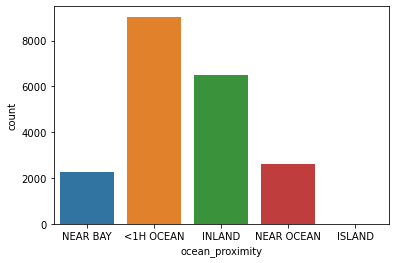

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
def cat_analysis(col):
  housing[col].value_counts()
  sns.countplot(x=col,data=housing)
  plt.show()

for i in cat:
  cat_analysis(i)

array([[<AxesSubplot:title={'center':'median_income'}>]], dtype=object)

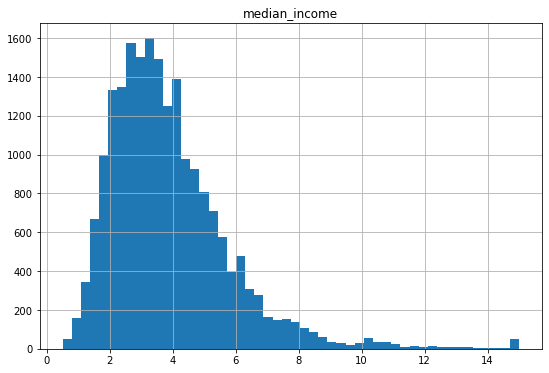

In [17]:
housing.hist(column='median_income', 
             bins=50, figsize=(9,6))

<AxesSubplot:>

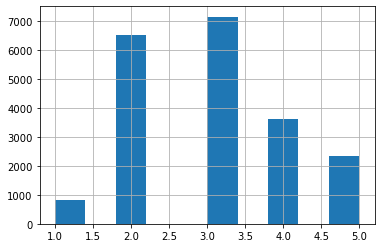

In [18]:
import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"], 
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                              labels=[1, 2, 3, 4, 5])

housing["income_cat"].hist()

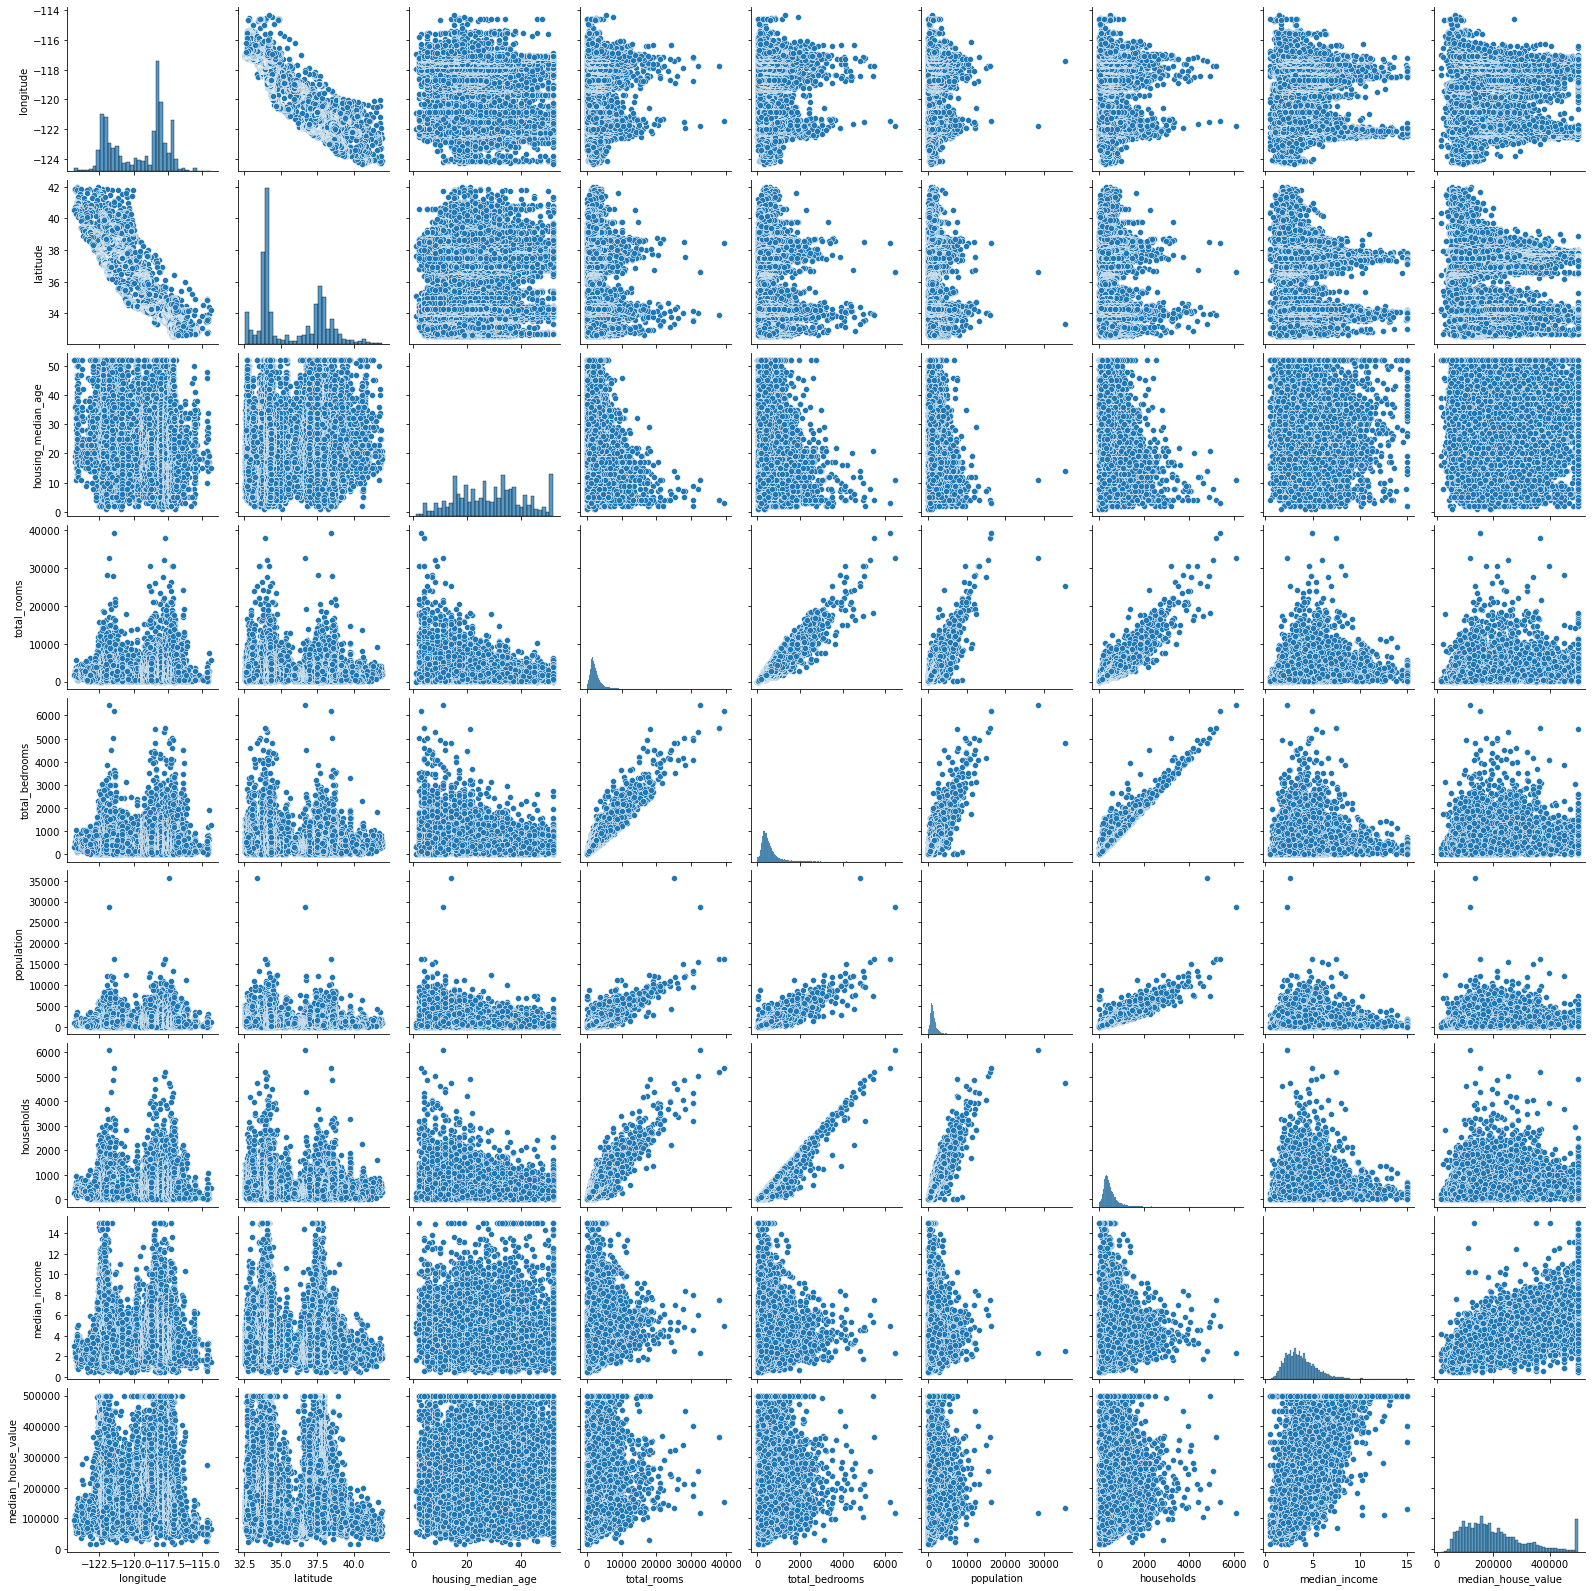

In [19]:
sns.pairplot(housing)
plt.show()

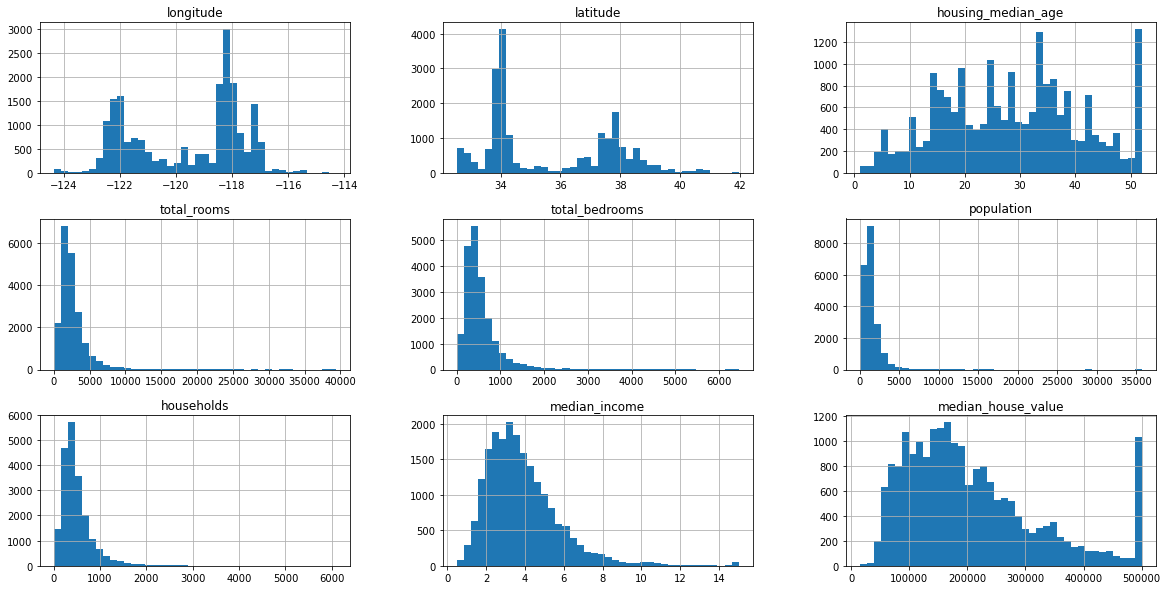

In [20]:
%matplotlib inline
housing.hist(bins=40,figsize=(20,10))
plt.show()

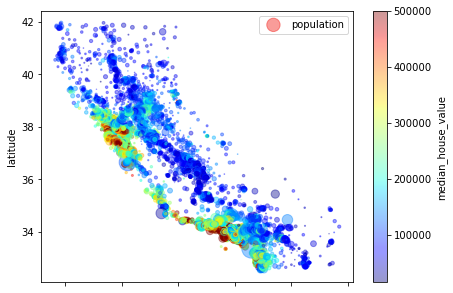

In [21]:
import matplotlib.pyplot as plt
# plot
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4, 
             s=housing["population"]/100, label="population", figsize=(7,5), 
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,)
plt.legend()


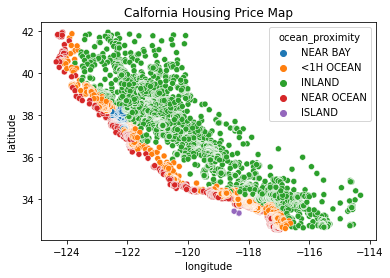

In [22]:
# let's see how actual calfornia dataset looks like 
sns.scatterplot(x=housing.longitude,y=housing.latitude,hue=housing['ocean_proximity'])
plt.title('Calfornia Housing Price Map')
plt.show()

In [23]:
# checking the correlation between different features
corr=housing.drop(columns=['ocean_proximity']).corr()
corr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000


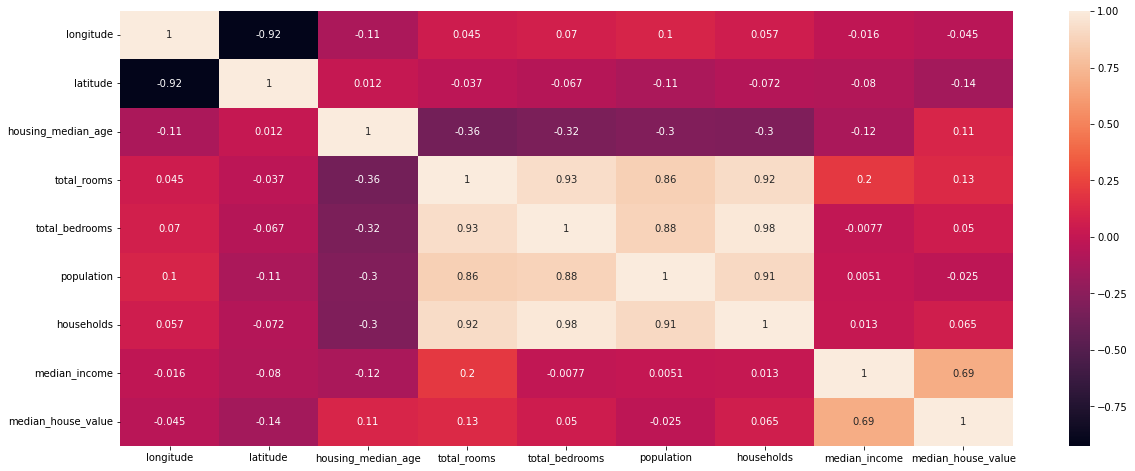

In [24]:
plt.figure(figsize=(20,8))
sns.heatmap(corr,annot=True)
plt.show()


In [25]:
#To ,get rid of multicollinearity we try some new features in our dataset

housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [26]:
corr1=housing.drop(columns=['ocean_proximity']).corr()
corr1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,-0.027307,0.092657,0.002304
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,0.106423,-0.113815,0.002522
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,-0.153031,0.136089,0.013258
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,0.133482,-0.187900,-0.024596
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.001538,0.084238,-0.028355
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,-0.071898,0.035319,0.070062
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,-0.080165,0.065087,-0.027336
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.325307,-0.615661,0.018894
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.151344,-0.255880,-0.023639
rooms_per_household,-0.027307,0.106423,-0.153031,0.133482,0.001538,-0.071898,-0.080165,0.325307,0.151344,1.000000,-0.416952,-0.004873


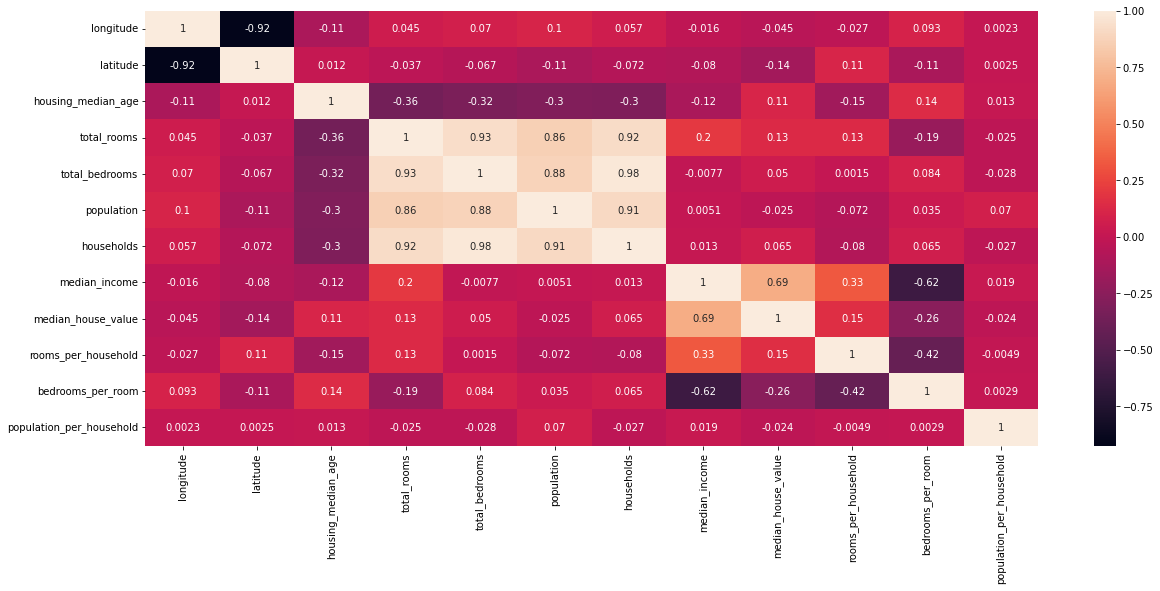

In [27]:
plt.figure(figsize=(20,8))
sns.heatmap(corr1,annot=True)
plt.show()

In [28]:
housing.drop(columns=['total_rooms','total_bedrooms','population','households'],inplace=True)

In [29]:
housing.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,8.3252,452600.0,NEAR BAY,5,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,8.3014,358500.0,NEAR BAY,5,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,7.2574,352100.0,NEAR BAY,5,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,5.6431,341300.0,NEAR BAY,4,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,3.8462,342200.0,NEAR BAY,3,6.281853,0.172096,2.181467


In [30]:
housing[housing['median_house_value']>=500000]

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_household,bedrooms_per_room,population_per_household
89,-122.27,37.80,52.0,1.2434,500001.0,NEAR BAY,1,2.929412,0.313253,4.658824
459,-122.25,37.87,52.0,1.1696,500001.0,NEAR BAY,1,2.436000,0.387521,5.396000
493,-122.24,37.86,52.0,7.8521,500001.0,NEAR BAY,5,7.794393,0.134892,2.415888
494,-122.24,37.85,52.0,9.3959,500001.0,NEAR BAY,5,7.512097,0.127214,2.754032
509,-122.23,37.83,52.0,7.8772,500001.0,NEAR BAY,5,8.282548,0.126756,2.623269
...,...,...,...,...,...,...,...,...,...,...
20422,-118.90,34.14,35.0,5.1457,500001.0,<1H OCEAN,4,6.958333,0.174983,2.666667
20426,-118.69,34.18,11.0,10.0472,500001.0,<1H OCEAN,5,9.890756,0.117247,3.487395
20427,-118.80,34.19,4.0,8.6499,500001.0,<1H OCEAN,5,7.236059,0.142692,2.553439
20436,-118.69,34.21,10.0,12.5420,500001.0,<1H OCEAN,5,9.873315,0.111657,3.177898


Capped values: 958 out of 20433 (4.69%)


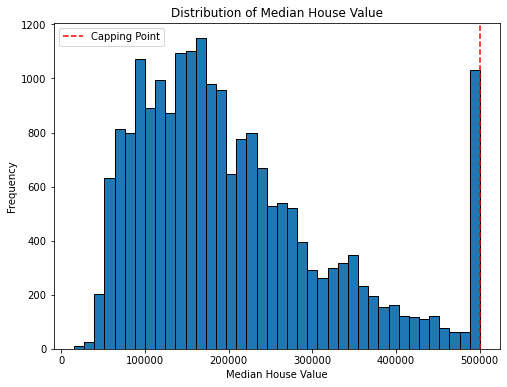

In [31]:
capped_values = housing[housing['median_house_value'] >= 500001]
print(f"Capped values: {len(capped_values)} out of {len(housing)} ({len(capped_values)/len(housing)*100:.2f}%)")


plt.figure(figsize=(8, 6))
plt.hist(housing['median_house_value'], bins=40, edgecolor='black')
plt.axvline(x=500001, color='r', linestyle='--', label='Capping Point')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.legend()
plt.show()

Percentage of outliers in longitude 0.0


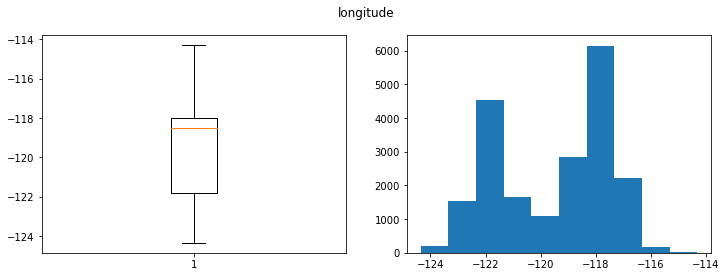

None
+++====+++
Percentage of outliers in latitude 0.0


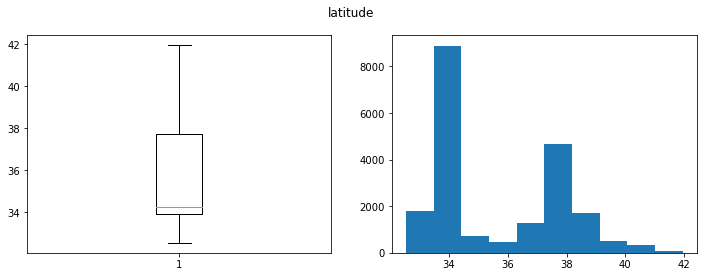

None
+++====+++
Percentage of outliers in housing_median_age 0.0


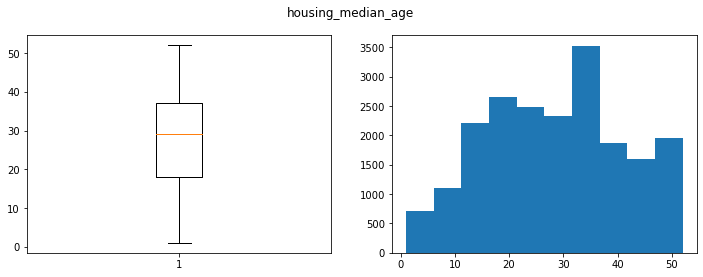

None
+++====+++
Percentage of outliers in median_income 3.2790094455048204


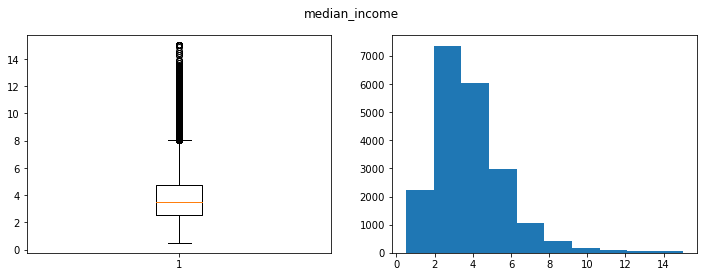

None
+++====+++
Percentage of outliers in median_house_value 5.207262761219596


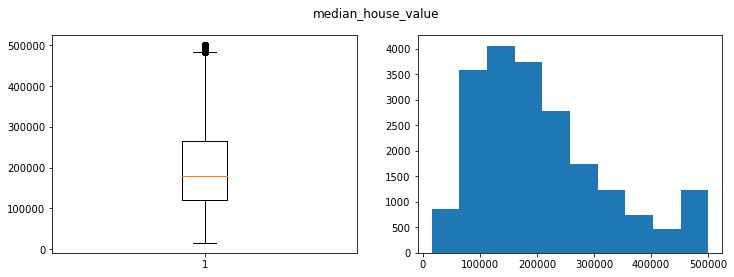

None
+++====+++
Percentage of outliers in rooms_per_household 2.4861743258454463


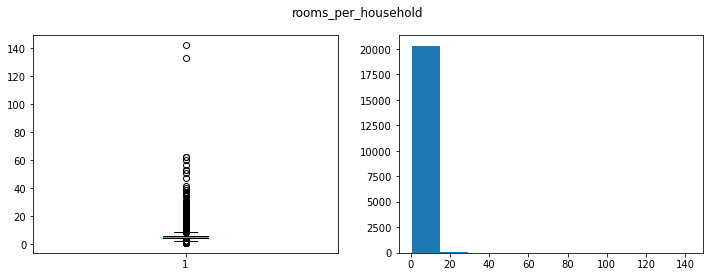

None
+++====+++
Percentage of outliers in bedrooms_per_room 2.8483335780355308


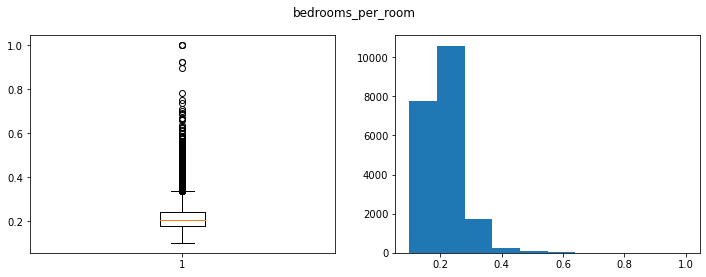

None
+++====+++
Percentage of outliers in population_per_household 3.4698771594968925


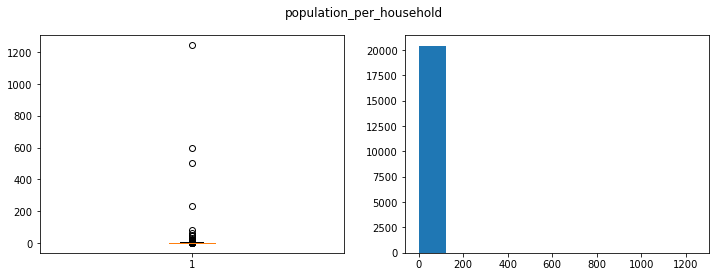

None
+++====+++


In [32]:
import matplotlib.pyplot as plt

# Treating Numerical Values
def outlier_detection_treatment(col):      # calculating the % of outliers & treating them
    q1= housing[col].quantile(0.25)
    q3= housing[col].quantile(0.75)
    iqr= q3-q1
    lf= q1- 1.5*iqr
    uf= q3+ 1.5*iqr
    outliers= housing[(housing[col]<lf) | (housing[col]>uf)]
    print("Percentage of outliers in", col ,outliers.shape[0]*100/housing.shape[0])
    fig, ax= plt.subplots(1,2, figsize=(12,4))
    ax[0].boxplot(housing[col])
    ax[1].hist(housing[col])
    plt.suptitle(col)
    plt.show()
    housing.loc[(housing[col]<lf) | (housing[col]>uf), col]= housing[col].median()

num = housing.select_dtypes(include='number').columns.tolist()

for col in num:
    print(outlier_detection_treatment(col))
    print("+++====+++")

In [33]:
housing = housing.reset_index(drop=True)

In [34]:
from sklearn.preprocessing import OneHotEncoder

In [35]:
from sklearn.preprocessing import OneHotEncoder

# fetch ocean_proximity
housing_cat = housing[["ocean_proximity"]]
# one hot encoder
cat_encoder = OneHotEncoder()
housing_cat_encoder = cat_encoder.fit_transform(housing_cat)
# convert sparse matrix to array to dispaly the result
result = housing_cat_encoder.toarray()
print("Data:")
print(result)
category_list = cat_encoder.categories_
print("Category List::", category_list)

Data:
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Category List:: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [36]:
ohe_ocean=OneHotEncoder(sparse=False)
ocean_arr=ohe_ocean.fit_transform(housing[['ocean_proximity']])
ocean=pd.DataFrame(ocean_arr, columns=ohe_ocean.categories_)

In [37]:
ocean=ocean.drop('ISLAND', axis=1)

In [38]:
ocean

,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
20428,0.0,1.0,0.0,0.0
20429,0.0,1.0,0.0,0.0
20430,0.0,1.0,0.0,0.0
20431,0.0,1.0,0.0,0.0


In [39]:
x=housing.drop(['ocean_proximity', 'median_house_value'],axis=1)
y=housing['median_house_value']

In [40]:
x.shape

(20433, 8)

In [41]:
x=pd.concat([x,ocean],axis=1)

In [42]:
x.shape

(20433, 12)

In [43]:
x=x.values
y=y.values

In [44]:
x.shape

(20433, 12)

In [45]:
y.shape

(20433,)

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)

In [48]:
y_test.shape

(6130,)

In [49]:
x_train.shape

(14303, 12)

In [50]:
housing.shape

(20433, 10)

In [51]:
import pandas as pd
housing = pd.read_csv("C:\\Users\\navee\\OneDrive\\Desktop\\PRIYA DOCUMENT\\housing.csv")


housing=housing.sample(20640)
housing=housing.sample(20640)
housing=housing.sample(20640)
housing=housing.sample(20640)

In [52]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8717,-118.36,33.84,22.0,11016.0,3170.0,6664.0,2838.0,3.7030,361300.0,<1H OCEAN
3353,-121.03,40.35,52.0,5486.0,1044.0,1977.0,754.0,2.1833,49500.0,INLAND
13395,-117.58,34.02,4.0,5998.0,1092.0,3182.0,1042.0,5.2692,174800.0,INLAND
4500,-118.21,34.05,28.0,950.0,357.0,1485.0,345.0,1.9271,136400.0,<1H OCEAN
18894,-122.24,38.13,37.0,3223.0,564.0,1325.0,539.0,4.0938,126900.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
19159,-122.70,38.36,11.0,5817.0,878.0,2538.0,876.0,4.2210,227100.0,<1H OCEAN
12712,-121.40,38.59,18.0,2614.0,624.0,1181.0,616.0,2.0432,156800.0,INLAND
2872,-118.95,35.37,37.0,1475.0,327.0,946.0,295.0,1.6728,55400.0,INLAND
5681,-118.29,33.71,31.0,2809.0,666.0,1316.0,633.0,4.5606,303800.0,NEAR OCEAN


In [53]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

In [55]:
x_train,x_test,y_train,y_test=train_test_split(housing.drop(columns=['median_house_value']),housing['median_house_value'],test_size=0.20,random_state=42)

In [56]:
x_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
5533,-118.42,33.96,44.0,1282.0,216.0,494.0,209.0,5.6180,<1H OCEAN
4696,-118.37,34.07,39.0,2309.0,526.0,870.0,546.0,3.1677,<1H OCEAN
14012,-117.17,32.75,38.0,5430.0,1176.0,2357.0,1100.0,3.6540,NEAR OCEAN
2301,-119.78,36.82,25.0,5016.0,NaN,2133.0,928.0,3.6250,INLAND
13238,-117.67,34.13,10.0,2846.0,362.0,1221.0,355.0,7.7234,INLAND


In [57]:
x_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
10842,-117.91,33.67,16.0,7961.0,2276.0,5014.0,2116.0,3.5120,<1H OCEAN
4677,-118.34,34.08,52.0,1421.0,163.0,495.0,167.0,10.5860,<1H OCEAN
19876,-119.31,36.33,46.0,1636.0,338.0,772.0,332.0,2.4250,INLAND
6329,-117.95,33.98,15.0,16042.0,2602.0,7732.0,2552.0,5.6716,<1H OCEAN
2486,-120.37,36.15,34.0,2084.0,339.0,868.0,347.0,4.3810,INLAND


In [58]:
x_test['ocean_proximity'].value_counts()


<1H OCEAN     1807
INLAND        1321
NEAR OCEAN     565
NEAR BAY       434
ISLAND           1
Name: ocean_proximity, dtype: int64

In [59]:
num_attribute=list(housing.drop(columns=['ocean_proximity','median_house_value']))


In [60]:
num_attribute

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [61]:
cat_attribute=['ocean_proximity']


In [62]:
pipeline1=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('Scaler',StandardScaler())
    
],verbose=True)

In [63]:
pipeline2=Pipeline(steps=[
    ('Label Encoder',OneHotEncoder(sparse=False,drop='first',handle_unknown='ignore'))
])


In [64]:
preprocessor=ColumnTransformer(transformers=[
    ('Pipeline 1 For Numerical Columns ',pipeline1,num_attribute),
    ('Encoder For Cateogrical Columns',pipeline2,cat_attribute)
])

In [65]:
preprocessor

ColumnTransformer(transformers=[('Pipeline 1 For Numerical Columns ',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('Scaler', StandardScaler())],
                                          verbose=True),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('Encoder For Cateogrical Columns',
                                 Pipeline(steps=[('Label Encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse=False))]),
                                 [

In [66]:
x_train.shape

(16512, 9)

In [67]:
x_train_transformed=preprocessor.fit_transform(x_train)


[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.0s
[Pipeline] ............ (step 2 of 2) Processing Scaler, total=   0.0s


In [68]:
x_train_transformed.shape


(16512, 12)

In [69]:
x_test.shape


(4128, 9)

In [70]:
x_test_transformed=preprocessor.fit_transform(x_test)


[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.0s
[Pipeline] ............ (step 2 of 2) Processing Scaler, total=   0.0s


In [71]:
x_test_transformed.shape


(4128, 12)

In [72]:
x_test['ocean_proximity'].value_counts()


<1H OCEAN     1807
INLAND        1321
NEAR OCEAN     565
NEAR BAY       434
ISLAND           1
Name: ocean_proximity, dtype: int64

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, explained_variance_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [74]:
lr=LinearRegression()
lr.fit(x_train_transformed,y_train)

LinearRegression()

In [75]:
y_pred_lr=lr.predict(x_test_transformed)



In [76]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

print('Percentage Error',mean_absolute_percentage_error(y_test,y_pred_lr))
print('Mean Square Error',mean_squared_error(y_test,y_pred_lr))
#print('RMSE',root_mean_squared_error(y_test,y_pred_lr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print('R2 Score',r2_score(y_test,y_pred_lr))
print('Variance Score',explained_variance_score(y_test,y_pred_lr))

Percentage Error 0.28623235477250414
Mean Square Error 4775666590.840968
RMSE 69106.19791915172
R2 Score 0.6469961439645768
Variance Score 0.6471258464739578


In [77]:
cv_score_lr=cross_val_score(lr,x_train_transformed,y_train,cv=10,scoring='neg_mean_squared_error')

In [78]:
rmse_lr=np.sqrt(-cv_score_lr)
print('CV Scores',rmse_lr)
print('RMSE',rmse_lr.mean())

CV Scores [69991.13403479 69581.59954491 68271.31366844 67104.26730324
 67557.45319842 66431.31485902 71345.45434122 70660.91324069
 66297.86484964 69369.93516688]
RMSE 68661.12502072557


In [79]:
rfr=RandomForestRegressor(n_estimators=100,max_features=8)


In [80]:
rfr.fit(x_train_transformed,y_train)


RandomForestRegressor(max_features=8)

In [81]:
y_pred_rfr=rfr.predict(x_test_transformed)


In [82]:
print('Percentage Error',mean_absolute_percentage_error(y_test,y_pred_rfr))
print('Mean Square Error',mean_squared_error(y_test,y_pred_rfr))
#print('RMSE',root_mean_squared_error(y_test,y_pred_rfr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print('R2 Score',r2_score(y_test,y_pred_rfr))
print('Variance Score',explained_variance_score(y_test,y_pred_rfr))

Percentage Error 0.19258349394934965
Mean Square Error 2814450359.030268
RMSE 69106.19791915172
R2 Score 0.7919637373213246
Variance Score 0.7931221466938273


In [83]:
cv_score_rfr=cross_val_score(rfr,x_train_transformed,y_train,cv=10,scoring='neg_mean_squared_error')

In [84]:
rmse_rfr=np.sqrt(-cv_score_rfr)
print('CV Scores',rmse_rfr)
print('RMSE',rmse_rfr.mean())

CV Scores [48483.50904706 48869.12546841 49193.72240561 45709.92048804
 51066.08217537 47151.81551395 50907.00029501 49949.27633486
 46338.6429877  49299.48767682]
RMSE 48696.85823928351


In [85]:
import pandas as pd

housing = pd.read_csv("C:\\Users\\navee\\OneDrive\\Desktop\\PRIYA DOCUMENT\\housing.csv")
print(housing.head()) 
from sklearn.model_selection import train_test_split

# Define features and target
X = housing.drop("median_house_value", axis=1)  # Replace with your actual target column name if different
y = housing["median_house_value"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [86]:
# Convert categorical column to dummy variables
housing_encoded = pd.get_dummies(housing, drop_first=True)

# Now split into features and target
X = housing_encoded.drop("median_house_value", axis=1)
y = housing_encoded["median_house_value"]

# Train/test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
# Check for missing values
print("Missing values in training data:\n", x_train.isnull().sum())

# Option 1: Fill missing values (imputation)
x_train = x_train.fillna(x_train.median())
x_test = x_test.fillna(x_train.median())  # Use train median to avoid data leakage

# Option 2 (optional): Drop rows with missing values
# x_train = x_train.dropna()
# y_train = y_train[x_train.index]  # Sync target
# x_test = x_test.dropna()
# y_test = y_test[x_test.index]

Missing values in training data:
 longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


In [88]:
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train the model
model = LinearRegression()
model.fit(x_train, y_train)

# Make predictions
y_pred_train_lr = model.predict(x_train)
y_pred_test_lr = model.predict(x_test)

# Save the model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved as 'model.pkl'")

# Evaluate on training data
print('Training Data Evaluation')
print("Mean Squared Error:", mean_squared_error(y_train, y_pred_train_lr))
print("R^2 Score:", r2_score(y_train, y_pred_train_lr))

# Evaluate on testing data
print('\nTesting Data Evaluation')
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_test_lr))
print("R^2 Score:", r2_score(y_test, y_pred_test_lr))

Model saved as 'model.pkl'
Training Data Evaluation
Mean Squared Error: 4683203783.504253
R^2 Score: 0.6496648627123223

Testing Data Evaluation
Mean Squared Error: 4908290571.346426
R^2 Score: 0.6254382675296271


In [89]:
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_train_lr = model.predict(x_train)
y_pred_test_lr = model.predict(x_test)

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model savedimport pickle")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_train_lr = model.predict(x_train)
y_pred_test_lr = model.predict(x_test)
print("Model saved as 'model.pkl'")

print('Training Data Evaluation')
print("Mean Squared Error:", mean_squared_error(y_train, y_pred_train_lr))
print("R^2 Score:", r2_score(y_train, y_pred_train_lr))

print('\nTesting Data Evaluation')
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_test_lr))
print("R^2 Score:", r2_score(y_test, y_pred_test_lr))

Model savedimport pickle
Model saved as 'model.pkl'
Training Data Evaluation
Mean Squared Error: 4683203783.504253
R^2 Score: 0.6496648627123223

Testing Data Evaluation
Mean Squared Error: 4908290571.346426
R^2 Score: 0.6254382675296271


In [90]:
from sklearn.preprocessing import PolynomialFeatures
degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly_train = poly.fit_transform(x_train)
X_poly_test = poly.transform(x_test)
model = LinearRegression()
model.fit(X_poly_train, y_train)

y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)

# Evaluate the model
print("Training Data Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_train, y_train_pred))
print("R^2 Score:", r2_score(y_train, y_train_pred))

print("\nTesting Data Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_test_pred))
print("R^2 Score:", r2_score(y_test, y_test_pred))

Training Data Evaluation:
Mean Squared Error: 2987226696.334822
R^2 Score: 0.7765353541829437

Testing Data Evaluation:
Mean Squared Error: 7172246670.788345
R^2 Score: 0.4526711286413492


In [91]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

svr_pipeline = make_pipeline(StandardScaler(), SVR())
param_grid = {
    'svr__kernel': ['linear', 'rbf'],
    'svr__C': [0.01, 0.1, 0.5, 1.0],
    'svr__gamma': ['scale', 'auto']
}

random_search = RandomizedSearchCV(svr_pipeline, param_grid, n_iter=10, cv=3, verbose=2, n_jobs=-1, scoring='neg_mean_squared_error')
random_search.fit(x_train, y_train)

# Predictions and evaluation
y_pred_train_svr = random_search.best_estimator_.predict(x_train)
y_pred_test_svr = random_search.best_estimator_.predict(x_test)

print("Training Data Evaluation:")
print('SVR RMSE:',mean_squared_error(y_train,y_pred_train_svr)**0.5)
print('SVR R2 Score:',r2_score(y_train,y_pred_train_svr))

y_pred_test_svr=random_search.predict(x_test)

print("\nTesting Data Evaluation:")
print('SVR RMSE:',mean_squared_error(y_test,y_pred_test_svr))
print('SVR R2 Score:',r2_score(y_test,y_pred_test_svr))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Training Data Evaluation:
SVR RMSE: 109291.580306565
SVR R2 Score: 0.10645988836718878

Testing Data Evaluation:
SVR RMSE: 11633763424.008173
SVR R2 Score: 0.1122036236637054


In [92]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
param_grid={
    'max_depth':[10, 15, 20, 25, 30],
    'min_samples_split':[5,10,15],
    'min_samples_leaf':[2,4,6],
    'criterion':[ 'squared_error'],
    'max_features': ['sqrt']
}

gridtree=GridSearchCV(DecisionTreeRegressor(random_state=0),param_grid,cv=7,scoring='neg_mean_squared_error',verbose=2, n_jobs=-1)

gridtree.fit(x_train,y_train)

best_model = gridtree.best_estimator_

y_pred_traindt=best_model.predict(x_train)
y_pred_testdt=best_model.predict(x_test)

print("Training Data Evaluation:")
print('Decision Tree RMSE:',mean_squared_error(y_train,y_pred_traindt)**0.5)
print('Decision Tree R2 Score:',r2_score(y_train,y_pred_traindt))

print("\nTesting Data Evaluation:")
print('Decision Tree RMSE:',mean_squared_error(y_test,y_pred_testdt))
print('Decision Tree R2 Score:',r2_score(y_test,y_pred_testdt))





Fitting 7 folds for each of 45 candidates, totalling 315 fits
Training Data Evaluation:
Decision Tree RMSE: 45506.98990126686
Decision Tree R2 Score: 0.8450837908928893

Testing Data Evaluation:
Decision Tree RMSE: 3969755644.7388906
Decision Tree R2 Score: 0.6970597950215579


In [93]:
from sklearn.ensemble import RandomForestRegressor
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['squared_error'],
    'max_features': ['sqrt']
}
gridrf=GridSearchCV(RandomForestRegressor(random_state=0),param_grid_rf,cv=5,scoring='neg_mean_squared_error',verbose=2, n_jobs=-1)

gridrf.fit(x_train,y_train)

y_pred_trainrf=gridrf.predict(x_train)
y_pred_testrf=gridrf.predict(x_test)

print("Training Data Evaluation:")
print('Random Forest RMSE:',mean_squared_error(y_train,y_pred_trainrf)**0.5)
print('Random Forest R2 Score:',r2_score(y_train,y_pred_trainrf))

print("\nTesting Data Evaluation:")
print('Random Forest RMSE:',mean_squared_error(y_test,y_pred_testrf))
print('Random Forest R2 Score:',r2_score(y_test,y_pred_testrf))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Training Data Evaluation:
Random Forest RMSE: 19777.313358360803
Random Forest R2 Score: 0.9707399387403832

Testing Data Evaluation:
Random Forest RMSE: 2504769758.8368497
Random Forest R2 Score: 0.8088558762624424


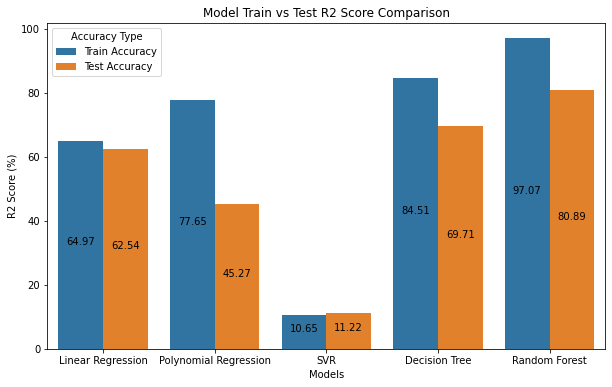

In [94]:
from sklearn import metrics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate accuracy scores for training and test data
train_score1 = metrics.r2_score(y_train, y_pred_train_lr)*100
train_score2 = metrics.r2_score(y_train, y_train_pred)*100
train_score3 = metrics.r2_score(y_train, y_pred_train_svr)*100
train_score4 = metrics.r2_score(y_train, y_pred_traindt)*100
train_score5 = metrics.r2_score(y_train, y_pred_trainrf)*100

test_score1 = metrics.r2_score(y_test, y_pred_test_lr)*100
test_score2 = metrics.r2_score(y_test, y_test_pred)*100
test_score3 = metrics.r2_score(y_test, y_pred_test_svr)*100
test_score4 = metrics.r2_score(y_test, y_pred_testdt)*100
test_score5 = metrics.r2_score(y_test, y_pred_testrf)*100

# Create a DataFrame for plotting
final_data = pd.DataFrame({
    'MODELS': ['Linear Regression', 'Polynomial Regression', 'SVR', 'Decision Tree', 'Random Forest'],
    "Train Accuracy": [train_score1, train_score2, train_score3, train_score4, train_score5],
    "Test Accuracy": [test_score1, test_score2, test_score3, test_score4, test_score5]
})

# Melt the DataFrame
final_data_melted = pd.melt(final_data, id_vars=['MODELS'], var_name='Accuracy Type', value_name='Accuracy')

# Plotting the stacked bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='MODELS', y='Accuracy', hue='Accuracy Type', data=final_data_melted)

# Add labels on top of each bar
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.2f', label_type='center', padding=3)

# Set labels and title
plt.xlabel('Models')
plt.ylabel('R2 Score (%)')
plt.title('Model Train vs Test R2 Score Comparison')

# Display the plot
plt.show()